In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('data/podcast_dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Podcast_Name                 52500 non-null  object 
 1   Episode_Title                52500 non-null  object 
 2   Episode_Length_minutes       47254 non-null  float64
 3   Genre                        52500 non-null  object 
 4   Host_Popularity_percentage   52500 non-null  float64
 5   Publication_Day              52500 non-null  object 
 6   Publication_Time             52500 non-null  object 
 7   Guest_Popularity_percentage  47242 non-null  float64
 8   Number_of_Ads                52500 non-null  int64  
 9   Episode_Sentiment            52500 non-null  object 
 10  Listening_Time_minutes       47105 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ MB


In [4]:
df.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559
2,Current Affairs,Episode 1,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645
3,Mystery Matters,Episode 38,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380
4,Humor Hub,Episode 73,83.48,Comedy,76.69,Tuesday,Afternoon,42.31,3,Positive,NaN


In [5]:
sns.set(style="darkgrid")

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/3451417625.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Host', 'Guest'], y=[host_mean, guest_mean], palette='Set2')


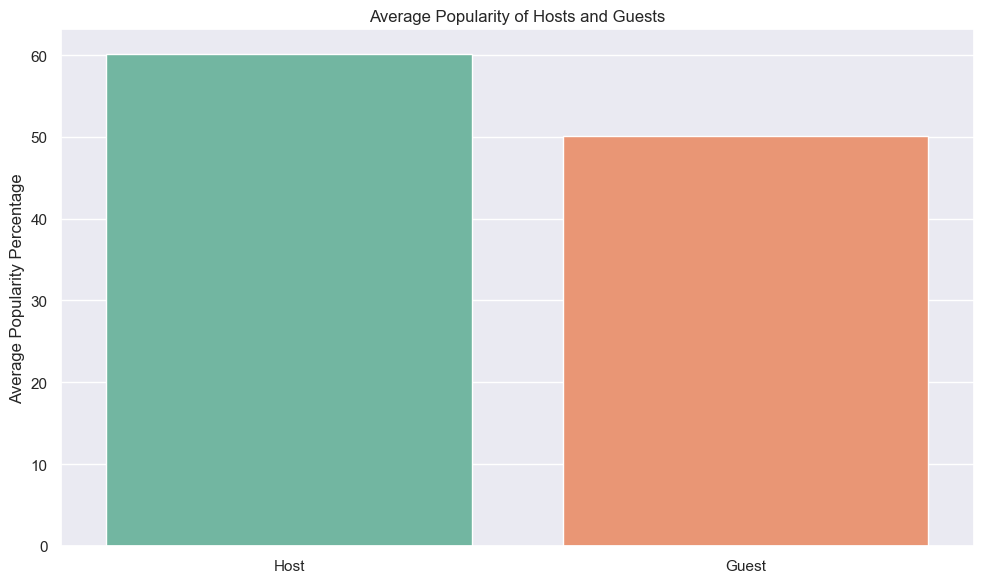

In [ ]:
#is it the host or the guest has a better impact to get a longer watching time  ? 

pop_df = df[['Host_Popularity_percentage','Guest_Popularity_percentage']].dropna()


host_mean = pop_df['Host_Popularity_percentage'].mean()
guest_mean = pop_df['Guest_Popularity_percentage'].mean()


plt.figure(figsize=(10, 6))
sns.barplot(x=['Host', 'Guest'], y=[host_mean, guest_mean], palette='Set2') 
plt.title('Average Popularity of Hosts and Guests')
plt.ylabel('Average Popularity Percentage')
plt.tight_layout()
plt.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/3733869316.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_watch['Percentage_Watched'] = (df_watch['Listening_Time_minutes'] / df_watch['Episode_Length_minutes']) * 100


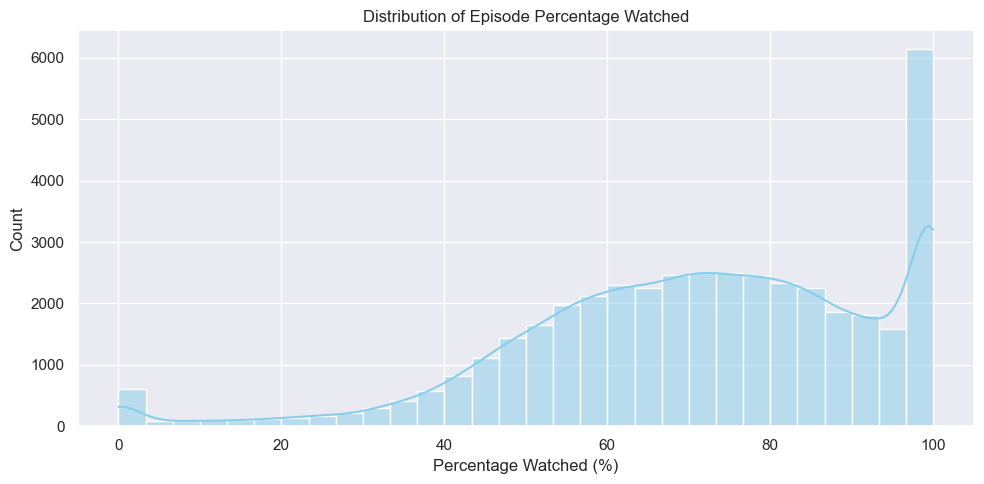

In [7]:
# Remove rows with nulls in either column
df_watch = df.dropna(subset=['Listening_Time_minutes', 'Episode_Length_minutes'])

# New column: percentage watched
df_watch['Percentage_Watched'] = (df_watch['Listening_Time_minutes'] / df_watch['Episode_Length_minutes']) * 100

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(df_watch['Percentage_Watched'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Episode Percentage Watched")
plt.xlabel("Percentage Watched (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/1563476081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_watch_avg.index, y=genre_watch_avg.values, palette='Set3')


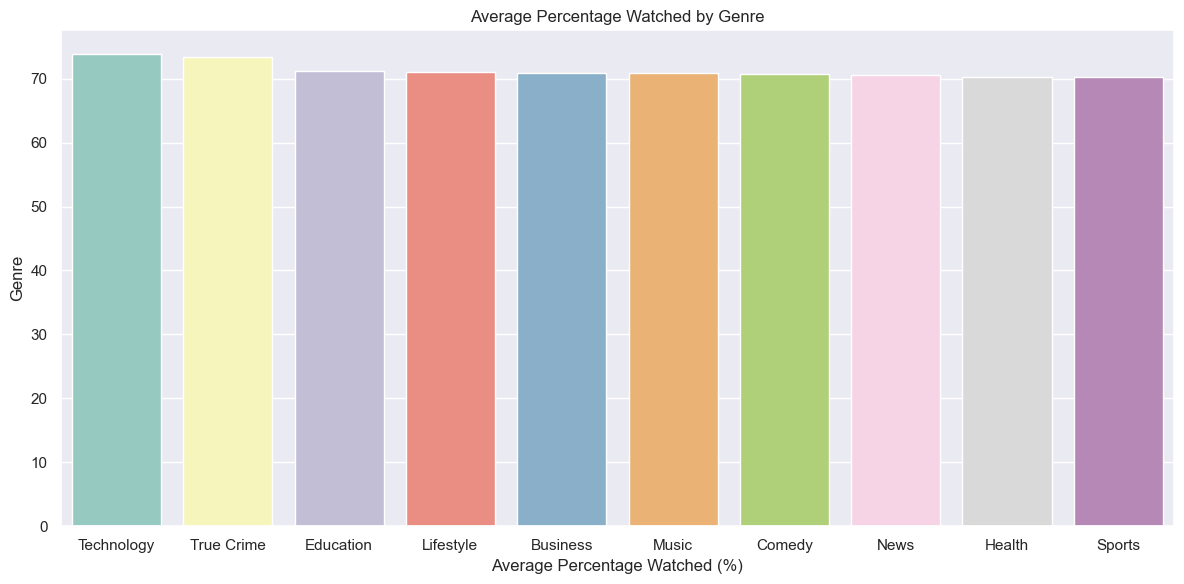

In [ ]:
#which genre is the most watched ?(i am checking the average percentage watched of full episode time and how long it was watched before moving on by genre) 
plt.figure(figsize=(12, 6))
genre_watch_avg = df_watch.groupby('Genre')['Percentage_Watched'].mean().sort_values(ascending=False)

sns.barplot(x=genre_watch_avg.index, y=genre_watch_avg.values, palette='Set3')
plt.title('Average Percentage Watched by Genre')
plt.xlabel('Average Percentage Watched (%)')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [9]:
df_time = df.dropna(subset= ['Listening_Time_minutes', 'Episode_Length_minutes','Publication_Time'])

df_time ['Percentage_Watched'] = (df_time['Listening_Time_minutes'] / df_time['Episode_Length_minutes']) * 100  


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/1777184894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time ['Percentage_Watched'] = (df_time['Listening_Time_minutes'] / df_time['Episode_Length_minutes']) * 100


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/79569621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Publication_Time', y='Percentage_Watched', estimator='mean', order=order, palette='Set2')


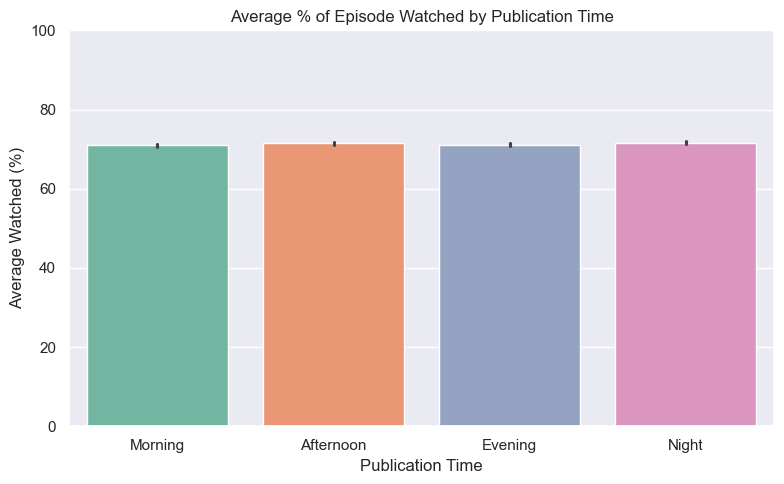

In [ ]:
#according to this, there is not much difference in the average percentage watched by time of day.

plt.figure(figsize=(8,5))
order = ['Morning', 'Afternoon', 'Evening', 'Night']  # Logical time order
sns.barplot(data=df_time, x='Publication_Time', y='Percentage_Watched', estimator='mean', order=order, palette='Set2')

plt.title('Average % of Episode Watched by Publication Time')
plt.ylabel('Average Watched (%)')
plt.xlabel('Publication Time')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


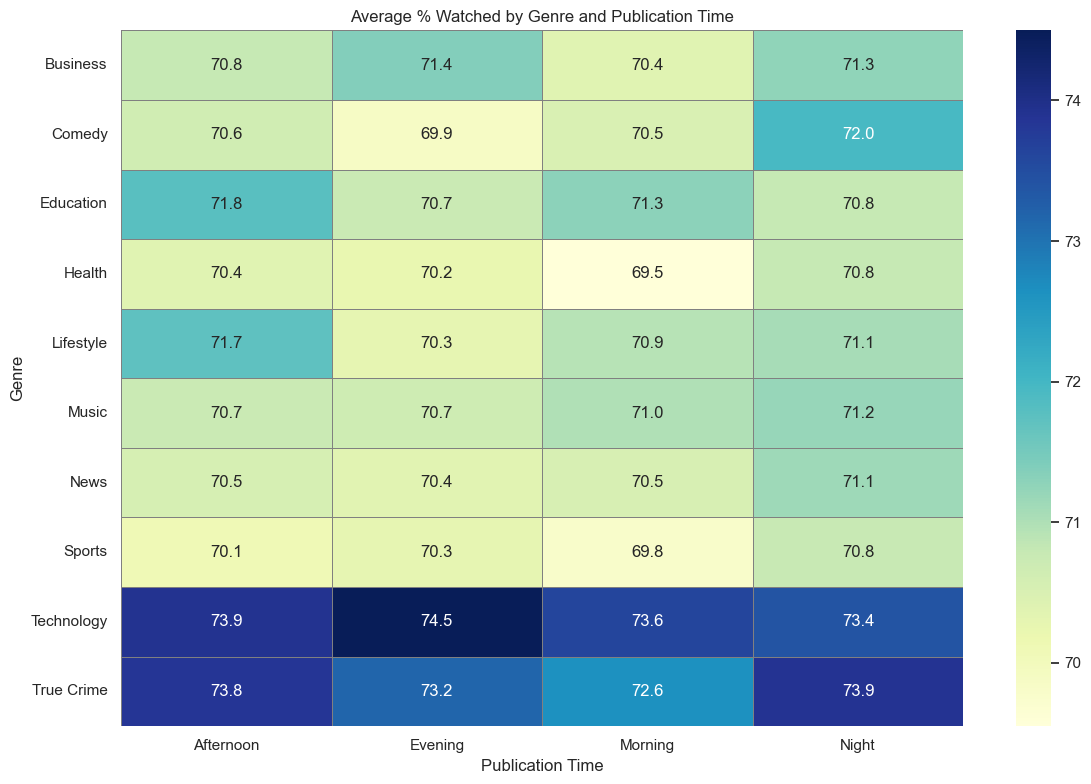

In [ ]:
 #which was the most watched genre by time of day ?
 # Clean & calculate %
df_time_genre = df.dropna(subset=['Listening_Time_minutes', 'Episode_Length_minutes', 'Publication_Time', 'Genre']).copy()
df_time_genre['Percentage_Watched'] = (df_time_genre['Listening_Time_minutes'] / df_time_genre['Episode_Length_minutes']) * 100

# Group & pivot
grouped = df_time_genre.groupby(['Publication_Time', 'Genre'])['Percentage_Watched'].mean().reset_index()
pivot = grouped.pivot(index='Genre', columns='Publication_Time', values='Percentage_Watched')

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Average % Watched by Genre and Publication Time")
plt.xlabel("Publication Time")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


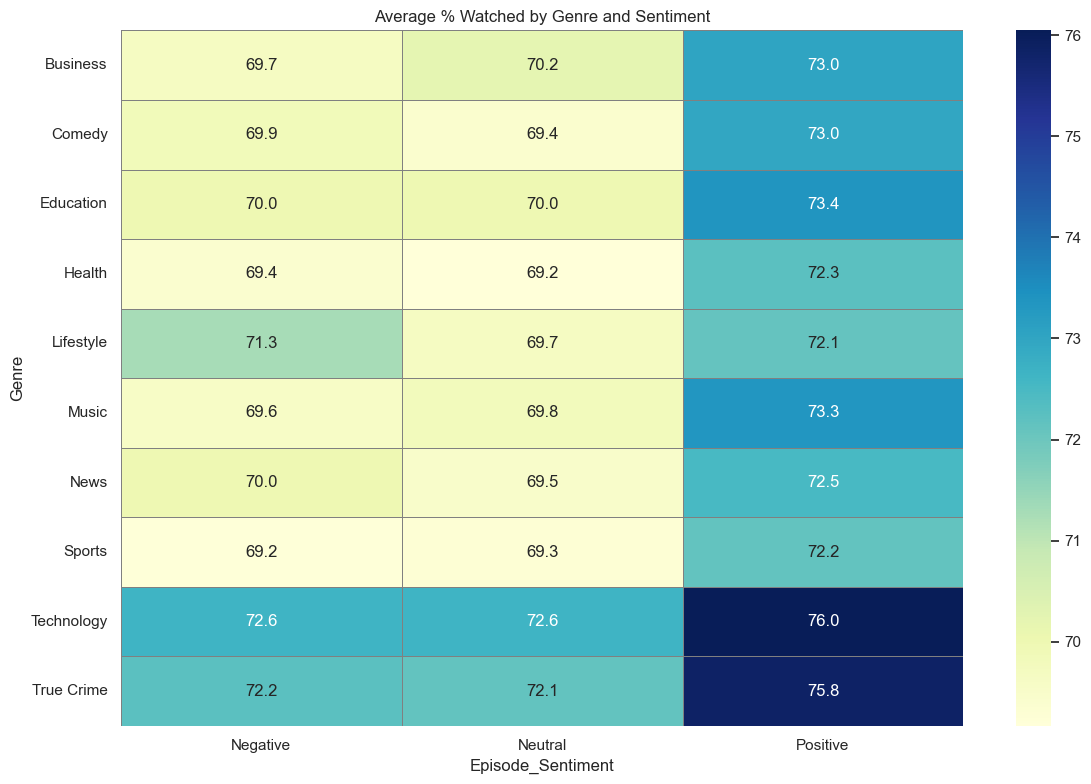

In [12]:
#do inspirational or homorous episodes get watched more, depending on their sentiment ? 

grouped_sent = df_time_genre.groupby(['Genre', 'Episode_Sentiment'])['Percentage_Watched'].mean().reset_index()
pivot_sent = grouped_sent.pivot(index='Genre', columns='Episode_Sentiment', values='Percentage_Watched')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_sent, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, linecolor='gray')
plt.title("Average % Watched by Genre and Sentiment")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation between Host Popularity and Percentage Watched')

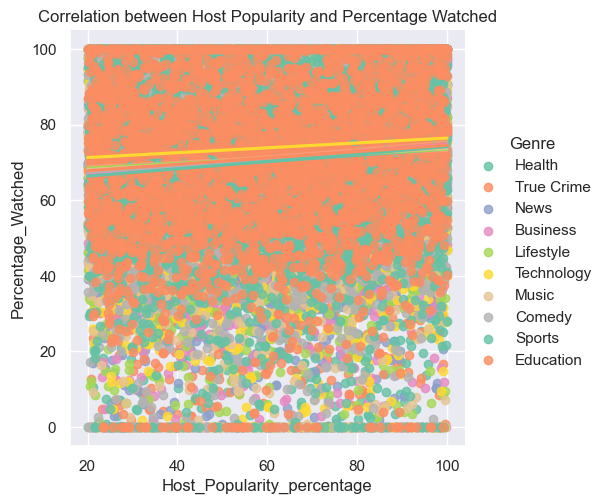

In [13]:
#does popularity correlate with retention? 

sns.lmplot(data=df_time_genre, x='Host_Popularity_percentage', y='Percentage_Watched', hue='Genre', palette='Set2')
plt.title('Correlation between Host Popularity and Percentage Watched') 

In [14]:
#so which genre i should focus on starting a podcast?

#preparing data
df_model = df.dropna(subset=[
    'Listening_Time_minutes',
    'Episode_Length_minutes',
    'Genre',
    'Publication_Time',
    'Episode_Sentiment',
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage'
]).copy()

df_model['Percentage_Watched'] = (df_model['Listening_Time_minutes'] / df_model['Episode_Length_minutes']) * 100    

df_encoded = pd.get_dummies(df_model[['Genre', 'Publication_Time', 'Episode_Sentiment']], drop_first=True)

X = pd.concat([
    df_model[['Host_Popularity_percentage', 'Guest_Popularity_percentage','Number_of_Ads']],
    df_encoded
], axis = 1)

y = df_model['Percentage_Watched']  




In [15]:
#train random forest regressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Mean Absolute Error: {mae:.2f}")


#mean absolute error is 16.68, which is decent, but we can improve it by tuning the model.

Mean Absolute Error: 16.68


In [16]:
# Create a base row (average values)
base = X.mean().to_frame().T

# For each genre, create a row where that genre's column is 1
genre_cols = [col for col in X.columns if col.startswith('Genre_')]
results = []

for col in genre_cols:
    row = base.copy()
    row[col] = 1  # Activate this genre
    predicted = model.predict(row)[0]
    genre_name = col.replace('Genre_', '')
    results.append((genre_name, predicted))

# Sort genres by predicted % watched
results = sorted(results, key=lambda x: x[1], reverse=True)
for genre, score in results:
    print(f"{genre}: Predicted Avg Engagement = {score:.2f}%")
    
#this results has a error rate of about 17%


Health: Predicted Avg Engagement = 71.89%
True Crime: Predicted Avg Engagement = 68.27%
Technology: Predicted Avg Engagement = 64.31%
Lifestyle: Predicted Avg Engagement = 64.13%
Music: Predicted Avg Engagement = 63.52%
Comedy: Predicted Avg Engagement = 59.56%
Sports: Predicted Avg Engagement = 58.93%
News: Predicted Avg Engagement = 57.79%
Education: Predicted Avg Engagement = 56.80%


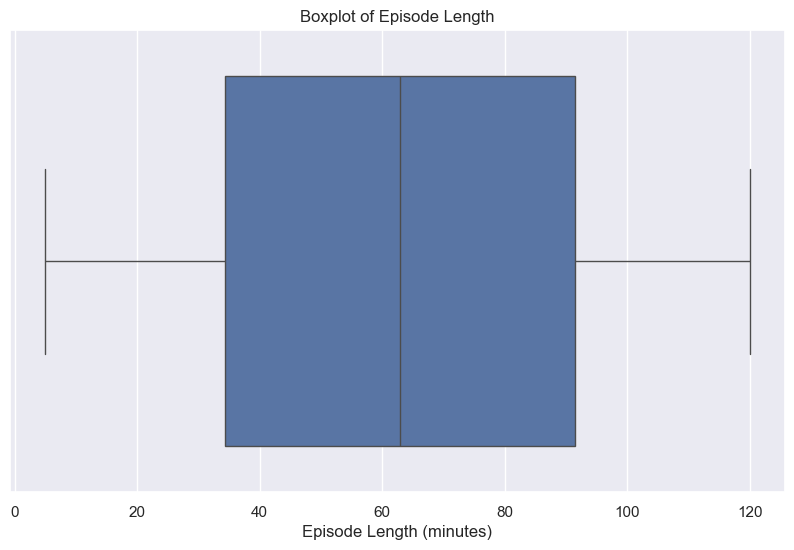

In [17]:
#lets tune this model a bit and find the outliers 

plt.figure(figsize=(10, 6))
sns.boxplot(x= df['Episode_Length_minutes'])
plt.title('Boxplot of Episode Length')
plt.xlabel('Episode Length (minutes)')
plt.show()

In [ ]:
#there isn't much of outliers (too long or too short episodes) but still lets see if we can clean up a bit 
# Drop rows with nulls in key columns first
df_clean = df.dropna(subset=[
    'Listening_Time_minutes', 'Episode_Length_minutes',
    'Genre', 'Publication_Time', 'Episode_Sentiment',
    'Host_Popularity_percentage', 'Guest_Popularity_percentage'
]).copy()

# Define bounds using percentiles
low_len = df_clean['Episode_Length_minutes'].quantile(0.01)
high_len = df_clean['Episode_Length_minutes'].quantile(0.99)

low_watch = df_clean['Listening_Time_minutes'].quantile(0.01)
high_watch = df_clean['Listening_Time_minutes'].quantile(0.99)

# Filter
df_clean = df_clean[
    (df_clean['Episode_Length_minutes'].between(low_len, high_len)) &
    (df_clean['Listening_Time_minutes'].between(low_watch, high_watch))
].copy()

# Recalculate % watched
df_clean['Percentage_Watched'] = (
    df_clean['Listening_Time_minutes'] / df_clean['Episode_Length_minutes']
) * 100


In [19]:
#see if the outliers affected the model
# One-hot encoding
df_encoded = pd.get_dummies(df_clean[['Genre', 'Publication_Time', 'Episode_Sentiment']], drop_first=True)

X = pd.concat([
    df_clean[['Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']],
    df_encoded
], axis=1)

y = df_clean['Percentage_Watched']

# Train/test split
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"New Mean Absolute Error after outlier removal: {mae:.2f}")

#didn't effect ,uch of the results so we will check for further tuning 


New Mean Absolute Error after outlier removal: 16.14


In [20]:
# lets run feautire engineering to see if we can improve the model

# going to add episode durations to see first 

def episode_lenght_bucket(length):
    if length < 30:
        return 'Short'
    elif 10 <= length<= 60:
        return 'Medium'
    else:
        return 'Long'   
    
df_clean['Episode_Length_Bucket'] = df_clean['Episode_Length_minutes'].apply(episode_lenght_bucket)

In [21]:
#also adding a bucket for episode days 

weekday_set = {'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'}
df_clean['is_weekend'] = df_clean['Publication_Day'].apply(lambda x: 0 if x in weekday_set else 1)

In [22]:
#rebulding the model with the new features

df_encoded = pd.get_dummies(df_clean[['Genre', 'Publication_Time', 'Episode_Sentiment', 'Episode_Length_Bucket']], drop_first=True)

X = pd.concat([
    df_clean[['Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 'is_weekend']],
    df_encoded
], axis=1)

y = df_clean['Percentage_Watched']

In [23]:
#train again 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Mean Absolute Error after feature engineering: {mae:.2f}")

#16.19 is still the same so this also didn't help much



Mean Absolute Error after feature engineering: 16.19


In [24]:
#lets try to tune the model a bit more with gridsearch 
# 
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto', 'sqrt']
}

In [25]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv = 3, n_jobs= 1, scoring = 'neg_mean_absolute_error', verbose = 2)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total

/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_con

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=2)

In [26]:
best_rf = grid_search.best_estimator_
preds =best_rf.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Absolute Error after Grid Search: {mae:.2f}")

#we are still at 16.15 % so not much of a difference



Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean Absolute Error after Grid Search: 16.15


In [27]:
from xgboost import XGBRegressor

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_

preds = best_xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, preds)
print(f"MAE with GridSearch-tuned XGBoost: {mae_xgb:.2f}")
print("Best parameters:", grid_search_xgb.best_params_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsamp

/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=10, n_estimators=200, subsample=0.8; total time=   1.1s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=10, n_estimators=200, subsample=1; total time=   0.9s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=10, n_estimators=200, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=1, learning_rate=0.05, max_depth=10, n_estimators=200, subsample=1; total time=   0.9s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=1; total time=   0.2s
[CV] END colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=100, subsample=0.8; to

In [28]:
import xgboost
print(xgboost.__version__)  # should now match the native .dylib version


2.1.4


In [29]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

lgb_model = LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)
lgb_mae = mean_absolute_error(y_test, lgb_preds)
print(f"Baseline LightGBM MAE: {lgb_mae:.2f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 29666, number of used features: 20
[LightGBM] [Info] Start training from score 71.066252
Baseline LightGBM MAE: 16.21


In [30]:
#optimizing the model with gridsearch again

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb = LGBMRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_lgb = grid_search.best_estimator_
lgb_preds_best = best_lgb.predict(X_test)
lgb_mae_best = mean_absolute_error(y_test, lgb_preds_best)

print(f"LightGBM MAE after Grid Search: {lgb_mae_best:.2f}")
print("Best LightGBM parameters:", grid_search.best_params_)



Fitting 3 folds for each of 96 candidates, totalling 288 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 19777, number of used features: 20
[LightGBM] [Info] Start training from score 71.203245
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 19777, number of used features: 20
[LightGBM] [Info] St

/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31, subsample=0.8; total time=   3.1s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 19777, number of used features: 20
[LightGBM] [Info] Start training from score 71.203245
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31, subsample=0.8; total time=   3.1s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.00

In [ ]:
"""so i run 3 different models and the best one was the lightgbm with a mean absolute error of 15.98 % but they are almost the same
    * so it tell us that the model is not very sensitive to the changes we made
    *lets check the features instead then 


""" 

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/1948760667.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


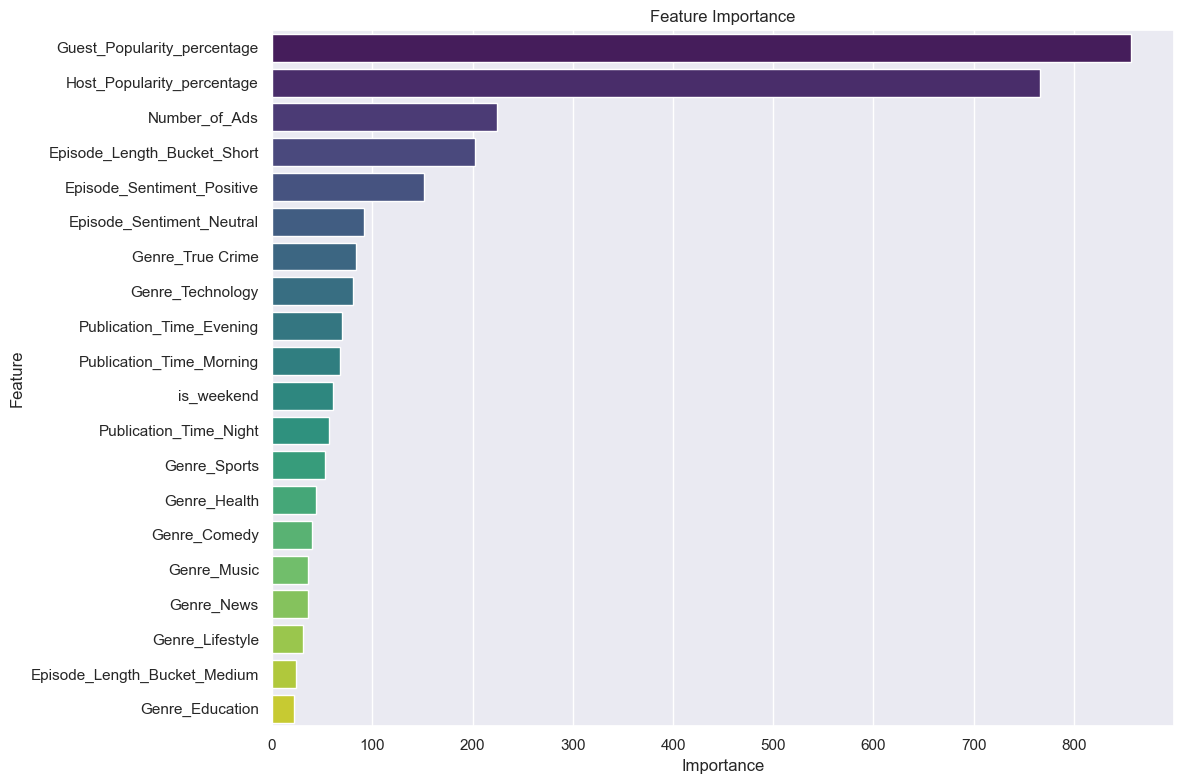

In [31]:
#feauture importance 

importances = best_lgb.feature_importances_
features = X_train.columns

importance_df  = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
"""
    * so the host makes the most impact on the model, followed by the guest and then the genre
    
    * so if we want to start a podcast, you should focus on the host and the guest first and then the genre"""

In [32]:
#guest and host popularity ratio 
df['Guest_Host_Popularity_Ratio'] = df['Guest_Popularity_percentage'] / (df['Host_Popularity_percentage'] +1)

In [33]:
# advert density

df['Ad_Density'] = df['Number_of_Ads'] / (df['Episode_Length_minutes'] +1)

In [34]:
df['Episode_Length_Category'] = pd.cut(
    df['Episode_Length_minutes'],
    bins=[0, 15, 45, df['Episode_Length_minutes'].max()],
    labels=['Short', 'Medium', 'Long']
)


In [35]:
# is there a guest ? 

df['Has_Guest'] = df['Guest_Popularity_percentage'].notnull().astype(int)
df['Has_Guest'] = df['Has_Guest'].replace({0: 'No', 1: 'Yes'})

In [36]:
columns_to_drop = [
    'Podcast_Name',
    'Episode_Title',
    'Publication_Day',   # Optional — unless we engineer 'Is_Weekend'
    'Publication_Time',  # You’ve likely one-hot encoded it already
    'Episode_Length_minutes'  # If you've bucketed it already
]

X = df.drop(columns=columns_to_drop + ['Listening_Time_minutes'])  # Target column is removed from features
y = df['Listening_Time_minutes']


In [37]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(0)


In [ ]:
# Train-test split again with nw features

In [38]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

best_lgb = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

best_lgb.fit(X_train, y_train)
preds = best_lgb.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"📊 MAE with engineered features: {mae:.2f}")


[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 29666, number of used features: 20
[LightGBM] [Info] Start training from score 71.066

In [39]:
#it is again 16.16. now lets try clusting genres and see 

genre_stats = df.groupby('Genre').agg({
    'Host_Popularity_percentage': 'mean',
    'Guest_Popularity_percentage': 'mean',
    'Listening_Time_minutes': 'mean',
    'Number_of_Ads': 'mean'
}).dropna().reset_index()

In [40]:
#normalize the data for clustering 

from sklearn.preprocessing import StandardScaler

features = genre_stats.drop('Genre', axis =1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [41]:
#using kmeans clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
genre_stats['Cluster'] = kmeans.fit_predict(features_scaled)

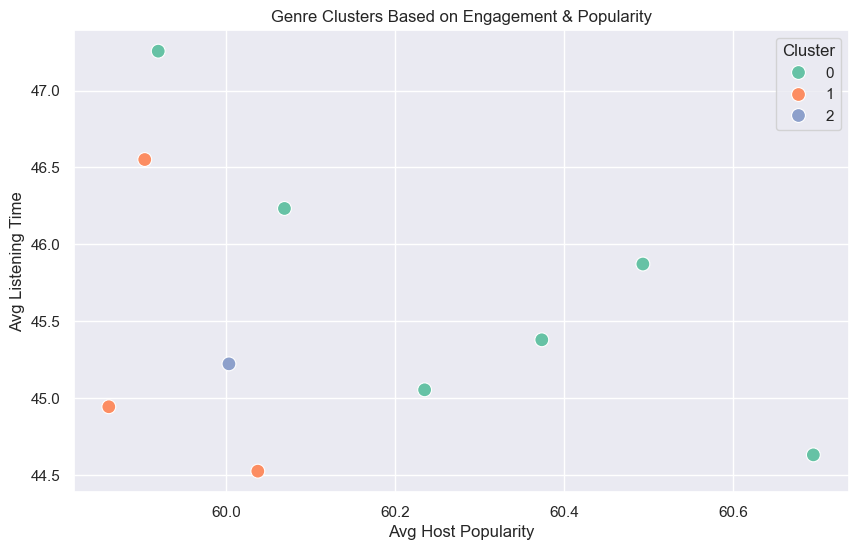

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Host_Popularity_percentage',
    y='Listening_Time_minutes',
    hue='Cluster',
    data=genre_stats,
    palette='Set2',
    s=100
)
plt.title('Genre Clusters Based on Engagement & Popularity')
plt.xlabel('Avg Host Popularity')
plt.ylabel('Avg Listening Time')
plt.grid(True)
plt.show()


In [ ]:
# taking the cluster results back to the original dataset

genre_cluster_map = genre_stats.set_index('Genre')['Cluster'].to_dict() 

df['Genre_Cluster'] = df['Genre'].map(genre_cluster_map)

In [44]:
df['Genre_Cluster'] = df['Genre_Cluster'].fillna(-1)


In [45]:
columns_to_drop = [
    'Podcast_Name',
    'Episode_Title',
    'Publication_Day',
    'Publication_Time',
    'Episode_Length_minutes',
    'Genre'  # Now replaced by Genre_Cluster
]

X = df.drop(columns=columns_to_drop + ['Listening_Time_minutes'])
y = df['Listening_Time_minutes']


In [46]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(0)


In [63]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error
# import lightgbm as lgb

# X_train, X_test, y_train, y_test = train_test_split(
#     X_encoded, y, test_size=0.2, random_state=42
# )

# model = lgb.LGBMRegressor(
#     n_estimators=200,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features='sqrt',
#     random_state=42
# )

# model.fit(X_train, y_train)
# preds = model.predict(X_test)
# mae = mean_absolute_error(y_test, preds)
# print(f"📊 MAE with Genre Clusters: {mae:.2f}")


In [57]:
#lets check the error and try to fix it 

print(X.isnull().sum())


Host_Popularity_percentage     0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Guest_Host_Popularity_Ratio    0
Ad_Density                     0
Episode_Length_Category        0
Has_Guest                      0
Genre_Cluster                  0
dtype: int64


In [49]:
X['Guest_Popularity_percentage'] = X['Guest_Popularity_percentage'].fillna(
    X['Guest_Popularity_percentage'].median()
)


In [50]:
X['Guest_Host_Popularity_Ratio'] = (
    X['Guest_Popularity_percentage'] / X['Host_Popularity_percentage']
)


In [51]:
df['Episode_Length_minutes'] = df['Episode_Length_minutes'].fillna(
    df['Episode_Length_minutes'].median()
)
X['Ad_Density'] = X['Number_of_Ads'] / df['Episode_Length_minutes']


In [52]:
X['Episode_Length_Category'] = X['Episode_Length_Category'].cat.add_categories(['Unknown']).fillna('Unknown')


In [53]:
print(X_encoded.isnull().sum()[X_encoded.isnull().sum() > 0])


Series([], dtype: int64)


In [54]:
X_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Retrain LightGBM or XGBoost and check new MAE


In [ ]:
#this part i get the error for having nan values and went to check if it is from the input or output and it turned out to be from the y so then i fixed it and run the code again

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"📊 MAE with Genre Clusters: {mae:.2f}")


[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1039
[LightGBM] [Info] Number of data points in the train set: 42000, number of used features: 12
[LightGBM] [Info] Start training from score 41.009106
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warni

ValueError: Input contains NaN.

In [ ]:
#checking if nan values coming from encoded but they were not 
print("🔍 NaNs in X_encoded:")
print(X_encoded.isnull().sum()[X_encoded.isnull().sum() > 0])


🔍 NaNs in X_encoded:
Series([], dtype: int64)


In [ ]:
#i found the nan's here and cleaned them up 
print("🔍 NaNs in y:")
print(y.isnull().sum())


🔍 NaNs in y:
5395


In [61]:
# Drop rows where either X or y is NaN
combined = pd.concat([X_encoded, y], axis=1)
combined_clean = combined.dropna()

# Re-split cleaned data
X_clean = combined_clean.drop(columns=y.name)
y_clean = combined_clean[y.name]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)


In [64]:
df['Listening_Percentage'] = (
    df['Listening_Time_minutes'] / df['Episode_Length_minutes']
) * 100

# Drop rows where this target or input features are NaN
df_model = df.dropna(subset=['Listening_Percentage'])  # Drop if target is NaN


In [ ]:
# Use only rows with non-null target- running again 
X = df_model[[
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage',
    'Number_of_Ads',
    'Episode_Sentiment',
    'Guest_Host_Popularity_Ratio',
    'Ad_Density',
    'Episode_Length_Category',
    'Has_Guest',
    'Genre_Cluster'
]]

y = df_model['Listening_Percentage']


In [66]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [ ]:

#this time it works but i get a higher error rate of 18.44 %
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"📊 MAE with Clean Target: {mae:.2f}")


[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000993 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1037
[LightGBM] [Info] Number of data points in the train set: 37684, number of used features: 11
[LightGBM] [Info] Start training from score 71.479815
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warni

In [68]:
df_model['Host_Ads_Interaction'] = df_model['Host_Popularity_percentage'] * df_model['Number_of_Ads']
df_model['Guest_Ads_Interaction'] = df_model['Guest_Popularity_percentage'] * df_model['Number_of_Ads']


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/929087861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Host_Ads_Interaction'] = df_model['Host_Popularity_percentage'] * df_model['Number_of_Ads']
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/929087861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Guest_Ads_Interaction'] = df_model['Guest_Popularity_percentage'] * df_model['Number_of_Ads']


In [69]:
def engagement_bucket(pct):
    if pct >= 80:
        return 'High'
    elif pct >= 50:
        return 'Medium'
    else:
        return 'Low'

df_model['Engagement_Level'] = df_model['Listening_Percentage'].apply(engagement_bucket)


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/2802411549.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Engagement_Level'] = df_model['Listening_Percentage'].apply(engagement_bucket)


In [70]:
df_model['Genre_Time'] = df_model['Genre'] + "_" + df_model['Publication_Time']


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/1665010489.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Genre_Time'] = df_model['Genre'] + "_" + df_model['Publication_Time']


/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


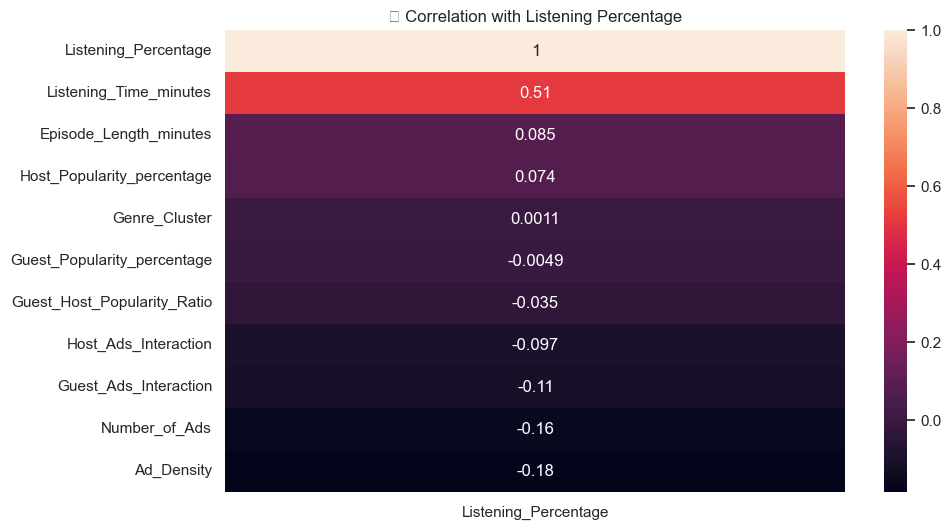

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check correlation heatmap to see what effects the listening percetage the most 
correlation_matrix = df_model.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix[['Listening_Percentage']].sort_values(by='Listening_Percentage', ascending=False), annot=True)
plt.title("📊 Correlation with Listening Percentage")
plt.show()


In [ ]:
#result after this is turned ou to be great. 1.30 . but why ? 

# Drop rows with missing target
df_model_clean = df_model.dropna(subset=['Listening_Percentage'])

# Define target and features
y = df_model_clean['Listening_Percentage']
X = df_model_clean.drop(columns=['Listening_Percentage', 'Podcast_Name', 'Episode_Title'])

# One-hot encode categorical features
X_encoded = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# LightGBM model
model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=10,
    min_child_samples=30,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit
model.fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"📊 MAE after feature engineering: {mae:.2f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000788 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2191
[LightGBM] [Info] Number of data points in the train set: 37684, number of used features: 82
[LightGBM] [Info] Start training from score 71.479815
📊 MAE after feature engineering: 1.30


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_24264/1829543892.py:9: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/utku-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


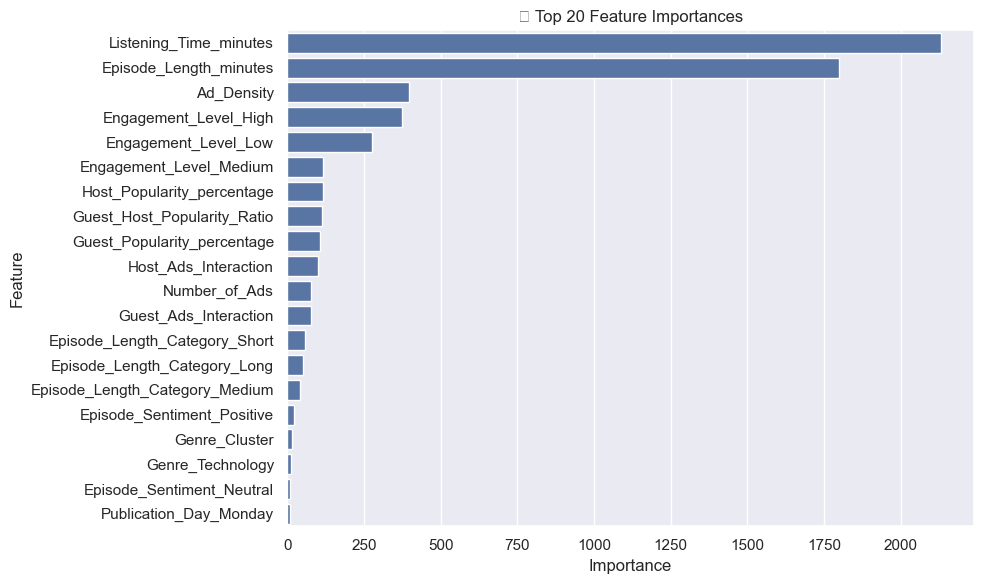

In [73]:
importances = model.feature_importances_
feature_names = X_encoded.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title("🔍 Top 20 Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
#what are the best options now in detail ? 

""" 1- tech 
    2- true crime 
    3. comedy 
    4. education
"""

best_combos = df_model.groupby('Genre_Time')['Listening_Percentage'].mean().sort_values(ascending=False)
print(best_combos.head(10))


Genre_Time
Technology_Evening      74.118230
True Crime_Afternoon    73.859670
Technology_Night        73.728907
True Crime_Night        73.719167
Technology_Morning      73.604440
Technology_Afternoon    73.119186
True Crime_Evening      72.643598
True Crime_Morning      72.588157
Comedy_Night            72.371409
Education_Morning       72.201739
Name: Listening_Percentage, dtype: float64


In [ ]:
# lets try an example . running a comedy podcast with a guest and 1 ad in the night time and see the prediction 
example = pd.DataFrame([{
    'Host_Popularity_percentage': 850,
    'Guest_Popularity_percentage': 900,
    'Number_of_Ads': 1,
    'Episode_Sentiment': 'Positive',
    'Episode_Length_minutes': 25,
    'Genre': 'Comedy',
    'Publication_Time': 'Night'
}])

# Feature engineering
example['Guest_Host_Popularity_Ratio'] = example['Guest_Popularity_percentage'] / example['Host_Popularity_percentage']
example['Ad_Density'] = example['Number_of_Ads'] / example['Episode_Length_minutes']
example['Episode_Length_Category'] = pd.cut(
    example['Episode_Length_minutes'],
    bins=[0, 20, 40, 60, 999],
    labels=['Very Short', 'Short', 'Medium', 'Long']
)
example['Has_Guest'] = example['Guest_Popularity_percentage'].apply(lambda x: 1 if x > 0 else 0)
example['Genre_Time'] = example['Genre'] + '_' + example['Publication_Time']

# Keep only required columns
features = [
    'Host_Popularity_percentage',
    'Guest_Popularity_percentage',
    'Number_of_Ads',
    'Episode_Sentiment',
    'Guest_Host_Popularity_Ratio',
    'Ad_Density',
    'Episode_Length_Category',
    'Has_Guest',
    'Genre_Time'
]

# One-hot encode like training
example_encoded = pd.get_dummies(example[features])
# Align with X_encoded from training
example_encoded = example_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# Predict
prediction = model.predict(example_encoded)[0]
print(f"🎧 Predicted Engagement (Listening %): {prediction:.2f}%")


🎧 Predicted Engagement (Listening %): 53.44%
